📚 Loading dataset...
✅ Loaded 925 cases.


/tmp/ipykernel_24/443174454.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_counts, palette="viridis")


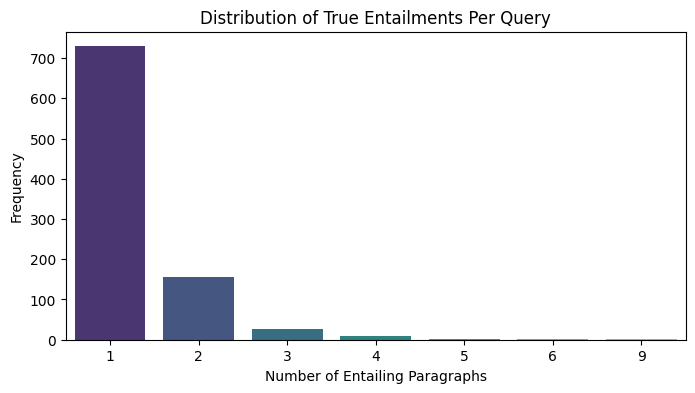

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import torch
import json
import random
import time
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from kaggle_secrets import UserSecretsClient
import huggingface_hub

# Clear ghost memory
gc.collect()
torch.cuda.empty_cache()

# --- Load Data ---
DATASET_ROOT = "/kaggle/input/datasets/vibhandutta/coliee26-task2" # UPDATE IF NEEDED
LABELS_FILE = os.path.join(DATASET_ROOT, "task2_train_labels_2026.json")
CASES_DIR = os.path.join(DATASET_ROOT, "cases-20260301T072723Z-1-001", "cases")

def load_labels(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

def read_text_file(filepath):
    if os.path.exists(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            return f.read().strip()
    return None

print("📚 Loading dataset...")
raw_labels = load_labels(LABELS_FILE)
labels = {k: [p.strip() for p in v] if isinstance(v, list) else [p.strip() for p in v.split(',')] for k, v in raw_labels.items()}

my_data = []
for case_id in os.listdir(CASES_DIR):
    case_path = os.path.join(CASES_DIR, case_id)
    if not os.path.isdir(case_path): continue
    
    paras = {}
    p_dir = os.path.join(case_path, 'paragraphs')
    if os.path.exists(p_dir):
        paras = {f: read_text_file(os.path.join(p_dir, f)) for f in os.listdir(p_dir) if f.endswith('.txt')}
        
    my_data.append({
        'case_id': case_id,
        'entailed_fragment': read_text_file(os.path.join(case_path, 'entailed_fragment.txt')),
        'paragraphs': paras,
        'target_labels': labels.get(case_id, [])
    })

print(f"✅ Loaded {len(my_data)} cases.")

# --- VISUALIZATION 1: Target Distribution ---
target_counts = [len(c['target_labels']) for c in my_data]
plt.figure(figsize=(8, 4))
sns.countplot(x=target_counts, palette="viridis")
plt.title("Distribution of True Entailments Per Query")
plt.xlabel("Number of Entailing Paragraphs")
plt.ylabel("Frequency")
plt.show()

⛏️ Mining Hard Negatives...


/tmp/ipykernel_24/2057935884.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="bge_rank", data=df, palette="coolwarm")
/tmp/ipykernel_24/2057935884.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="lexical_overlap", data=df, palette="coolwarm")


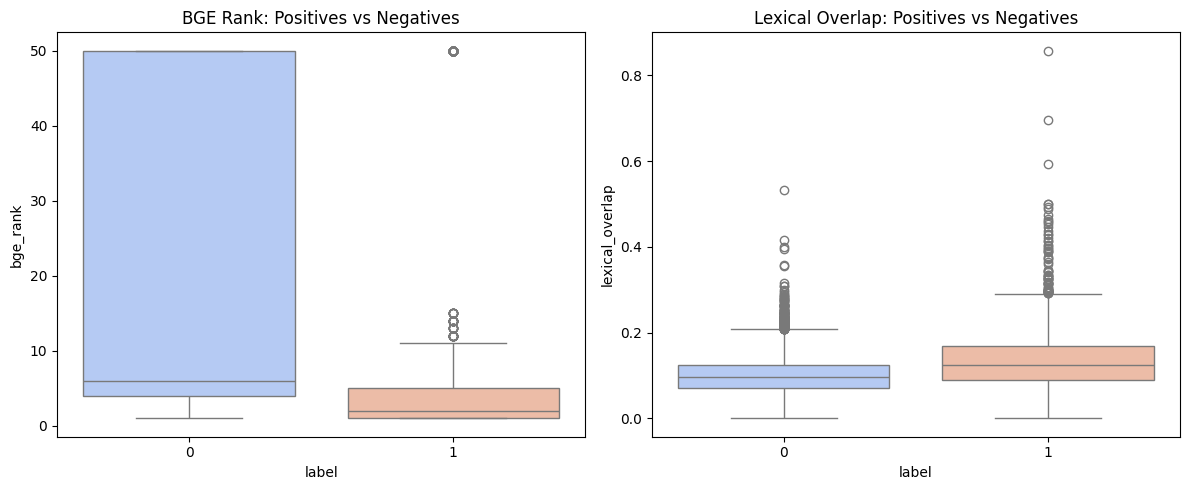

In [2]:
BGE_RESULTS_PATH = '/kaggle/input/datasets/vibhandutta/bge-results/bge_results_checkpoint.json' # UPDATE PATH

with open(BGE_RESULTS_PATH, 'r') as f:
    bge_map = {item.get("query_id", item.get("case_id", str(i))): item for i, item in enumerate(json.load(f))}

def get_jaccard_similarity(str1, str2):
    if not str1 or not str2: return 0
    a, b = set(str1.lower().split()), set(str2.lower().split())
    c = a.intersection(b)
    if len(a) + len(b) - len(c) == 0: return 0
    return float(len(c)) / (len(a) + len(b) - len(c))

print("⛏️ Mining Hard Negatives...")
data_rows = []
NUM_HARD_NEGATIVES, NUM_EASY_NEGATIVES, DEFAULT_BAD_RANK = 7, 3, 50

for case in my_data:
    case_id, q_text, gt, paras = case["case_id"], case["entailed_fragment"], set(case["target_labels"]), case["paragraphs"]
    if case_id not in bge_map: continue
        
    top_cands = [f if f.endswith('.txt') else f"{f}.txt" for f in bge_map[case_id].get("top_candidates", [])]
    added = set()
    
    # Extract helper
    def add_row(fname, rank, label):
        if fname in paras:
            data_rows.append({"query_id": case_id, "filename": fname, "bge_rank": rank, 
                              "q_len": len(q_text.split()), "p_len": len(paras[fname].split()), 
                              "length_diff": abs(len(q_text.split()) - len(paras[fname].split())), 
                              "lexical_overlap": get_jaccard_similarity(q_text, paras[fname]), "label": label})
            added.add(fname)

    # 1. Positives
    for f in gt: add_row(f, top_cands.index(f) + 1 if f in top_cands else DEFAULT_BAD_RANK, 1)
    # 2. Hard Negatives
    hard_added = 0
    for i, f in enumerate(top_cands):
        if hard_added >= NUM_HARD_NEGATIVES: break
        if f not in added:
            add_row(f, i + 1, 0); hard_added += 1
    # 3. Easy Negatives
    remaining = list(set(paras.keys()) - added)
    random.shuffle(remaining)
    for f in remaining[:NUM_EASY_NEGATIVES]: add_row(f, DEFAULT_BAD_RANK, 0)

df = pd.DataFrame(data_rows)

# --- VISUALIZATION 2: Feature Separation ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x="label", y="bge_rank", data=df, palette="coolwarm")
plt.title("BGE Rank: Positives vs Negatives")

plt.subplot(1, 2, 2)
sns.boxplot(x="label", y="lexical_overlap", data=df, palette="coolwarm")
plt.title("Lexical Overlap: Positives vs Negatives")
plt.tight_layout()
plt.show()

/tmp/ipykernel_24/2028360489.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_xgb.feature_importances_, y=features, palette="viridis")


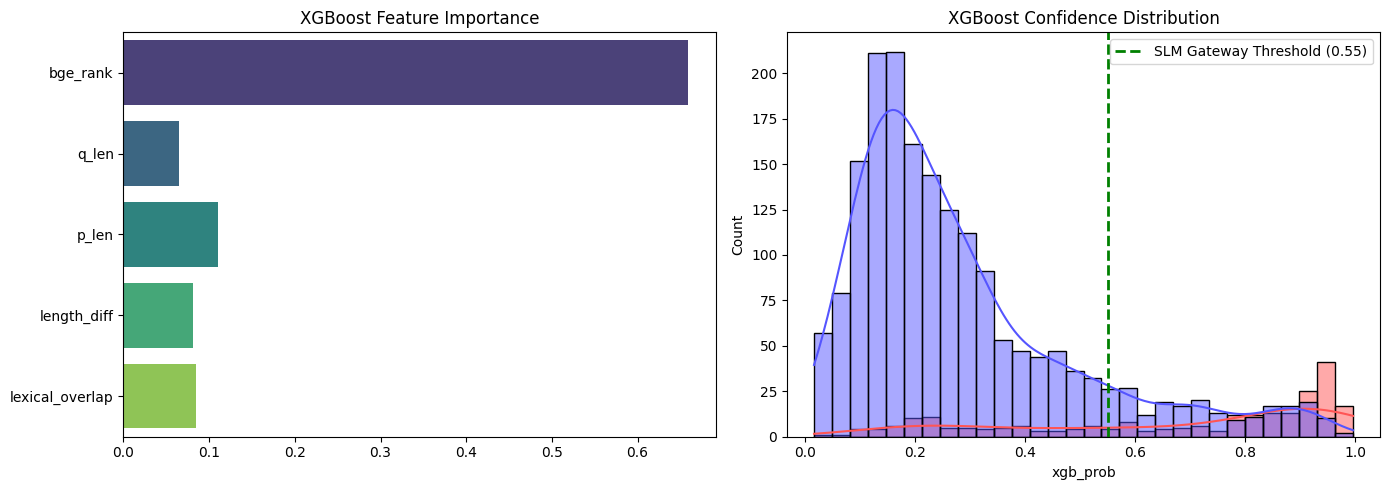

In [3]:
features = ["bge_rank", "q_len", "p_len", "length_diff", "lexical_overlap"]

train_queries, test_queries = train_test_split(df['query_id'].unique(), test_size=0.2, random_state=42)
train_df, test_df = df[df['query_id'].isin(train_queries)], df[df['query_id'].isin(test_queries)].copy()

X_train, y_train = train_df[features], train_df["label"]
X_test, y_test = test_df[features], test_df["label"]

scale_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]) if sum(y_train) > 0 else 1
model_xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, scale_pos_weight=scale_weight, random_state=42)
model_xgb.fit(X_train, y_train)

test_df["xgb_prob"] = model_xgb.predict_proba(X_test)[:, 1] 

# --- VISUALIZATION 3: Feature Importance & Probability Distribution ---
plt.figure(figsize=(14, 5))

# Plot A: Feature Importance
plt.subplot(1, 2, 1)
sns.barplot(x=model_xgb.feature_importances_, y=features, palette="viridis")
plt.title("XGBoost Feature Importance")

# Plot B: Probability Calibration
plt.subplot(1, 2, 2)
sns.histplot(data=test_df, x="xgb_prob", hue="label", bins=30, kde=True, palette="seismic")
plt.axvline(0.55, color='green', linestyle='--', linewidth=2, label="SLM Gateway Threshold (0.55)")
plt.title("XGBoost Confidence Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
print("🧹 Final VRAM Clear before LLM...")
gc.collect()
torch.cuda.empty_cache()

try:
    user_secrets = UserSecretsClient()
    huggingface_hub.login(token=user_secrets.get_secret("HF_TOKEN"))
except:
    print("⚠️ Check HF_TOKEN in Secrets!")

# USING LLAMA 3.2 3B FOR OOM SAFETY
model_id = "meta-llama/Llama-3.2-3B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True, bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
# SILENCE THE WARNING
tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_id, quantization_config=quantization_config, device_map={"": 0} 
)

# --- VISUALIZATION 4: GPU Memory Health Check ---
allocated = torch.cuda.memory_allocated(0) / 1024**3
reserved = torch.cuda.memory_reserved(0) / 1024**3
total = 15.0 # Kaggle T4 capacity

plt.figure(figsize=(8, 2))
plt.barh(["Kaggle T4 GPU"], [total], color='lightgray', label="Free VRAM")
plt.barh(["Kaggle T4 GPU"], [reserved], color='orange', label="Reserved VRAM")
plt.barh(["Kaggle T4 GPU"], [allocated], color='red', label="Allocated VRAM (Llama)")
plt.legend(loc="upper right")
plt.title(f"GPU Memory Check: {allocated:.2f} GB Used")
plt.show()

🧹 Final VRAM Clear before LLM...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

ImportError: Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`

In [ ]:
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

CONFIDENCE_THRESHOLD = 0.85
TOP_K_SLM = 4               

xgboost_handled, slm_handled = 0, 0
total_tp, total_ret, total_rel = 0, 0, 0
text_lookup = {item["case_id"]: item for item in my_data}

# UPDATED: Foolproof Prompting & Tokenization
def get_slm_decision(q_text, p_text):
    messages = [
        {"role": "system", "content": "You are an expert legal AI assistant. Determine if the specific legal paragraph entails the query fragment. Entailment means the core meaning or legal outcome of the query is supported by the paragraph, even if different words are used. Do not be overly strict."},
        {"role": "user", "content": f"Paragraph:\n\"{p_text}\"\n\nQuery:\n\"{q_text}\"\n\nDoes the Paragraph entail the Query?\nThink step-by-step. End your response with exactly one word: YES or NO."}
    ]
    
    # 1. Format the template into a raw text string first
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    # 2. Tokenize the text into a proper dictionary of tensors
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    
    # 3. Unpack the dictionary using **inputs
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=150, 
            temperature=0.0, 
            do_sample=False, 
            pad_token_id=tokenizer.eos_token_id
        )
        
    # 4. Decode correctly using input_ids shape
    input_length = inputs.input_ids.shape[1]
    response = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True).strip()
    
    return 1 if "YES" in response[-15:].upper() else 0

# ---------------- PIPELINE EXECUTION ----------------
start_time = time.time()
for qid in tqdm(test_queries, desc="Evaluating Hybrid Cascade"):
    q_data = test_df[test_df["query_id"] == qid].copy()
    if q_data.empty: continue
        
    gt = set(q_data[q_data["label"] == 1]["filename"].tolist())
    best_xgb_row = q_data.loc[q_data["xgb_prob"].idxmax()]
    predicted_file = None
    
    # ---------------- CASCADE ROUTING ----------------
    if best_xgb_row["xgb_prob"] >= CONFIDENCE_THRESHOLD:
        predicted_file = best_xgb_row["filename"]
        xgboost_handled += 1
    else:
        slm_handled += 1
        slm_found = False
        for _, row in q_data.nlargest(TOP_K_SLM, "xgb_prob").iterrows():
            p_text = text_lookup.get(qid, {}).get("paragraphs", {}).get(row["filename"], "")
            q_text = text_lookup.get(qid, {}).get("entailed_fragment", "")
            if get_slm_decision(q_text, p_text) == 1:
                predicted_file, slm_found = row["filename"], True
                break
        if not slm_found: predicted_file = best_xgb_row["filename"]
    # -------------------------------------------------

    if predicted_file:
        total_tp += len({predicted_file}.intersection(gt))
        total_ret += 1
    total_rel += len(gt)

# Final Scoring Math
p = total_tp / total_ret if total_ret > 0 else 0
r = total_tp / total_rel if total_rel > 0 else 0
f1 = 2 * (p*r)/(p+r) if (p+r) > 0 else 0

# --- VISUALIZATION 5: Final Performance ---
plt.figure(figsize=(12, 5))

# Plot A: Workload Pie Chart
plt.subplot(1, 2, 1)
plt.pie([xgboost_handled, slm_handled], labels=["XGBoost (Fast Path)", "Llama 3.2 (Heavy Path)"], autopct='%1.1f%%', colors=['#4CAF50', '#FF9800'])
plt.title(f"Routing Split (Threshold: {CONFIDENCE_THRESHOLD})")

# Plot B: Metrics Bar Chart
plt.subplot(1, 2, 2)
sns.barplot(x=["Precision", "Recall", "F1-Score"], y=[p, r, f1], palette="magma")
plt.ylim(0, 1.0)
for i, v in enumerate([p, r, f1]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.title("Final Hybrid Cascade Metrics")
plt.tight_layout()
plt.show()

print(f"\n⏱️ Total Runtime: {(time.time() - start_time) / 60:.2f} mins")